In [10]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import image_dataset_from_directory
import shutil
import pathlib

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
dev = tf.config.list_physical_devices()
print('Physical Devices : ', dev)

#tf.config.set_visible_devices(dev[0])
#tf.config.set_visible_devices(dev[1])
#dev = tf.config.list_logical_devices()
print('Available Devices : ', dev)

Physical Devices :  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Available Devices :  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Chapter 8: Introduction to Deep Learning for Computer Visison

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

**Convolutional neural networks** also known as **convnets**, are introduced in this chapter. 
Computer vision is the earliest and biggest success story of deep learning.  
A type of deep learning model called convolutional
neural networks started getting remarkably good results on image classification
competitions in the early 2010's. In these sections we will look at what
convnets are and how to use them to solve computer vision and image
classificatin tasks.

In [11]:
# reload needed data from previous section 8.2

# top level director where we will store our smaller dataset 
new_base_dir = pathlib.Path("../data/cats_vs_dogs_small")

# notice the image_size and batch_size parameters here
train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32)

validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=(180, 180),
    batch_size=32)

test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=(180, 180),
    batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


## 8.3 Leveraging a Pretrained Model

A common and highly effective approach to deep learning on small image datasets is to
use a pretrained model.  A **pretrained model** is a model that was previously trained
on a large dataset, typically on a large-scale image-classification task.

If the original dataset is large enough and general enough, the lower level of the
hierarchy of spatial features learned by the pretrained model can effectively act as
a generic model of the visual world. Such portability of
learned features across different problems is a key advantage of deep learning compared
to many older, shallow learning approaches, and it makes deep learning very
effective for small-data problems.

In this section we will show an example of leveraging a pretrained model.  We will use a large
convnet trained on the ImageNet dataset (1.4 million labeled images and 1000 different classes).  

We'll use the VGG16 architecture, developed in 2014.  The Keras API has access to several pretrained
models such as this one to use for projects.

### 8.3.1 Feature Extraction with a Pretrained Model

Feature extraction consists of using the representations learned by a previously
trained model to extract interesting features from new samples. These features are
then run through a new classifier, which is trained from scratch.

Convnets used for image classification comprise two parts:
they start with a series of pooling and convolution layers, and they end with a densely
connected classifier. The first part is called the convolutional base of the model. In the
case of convnets, feature extraction consists of taking the convolutional base of a previously
trained network, running the new data through it, and training a new classifier
on top of the output.

Note that the level of generality (and therefore reusability) of the representations
extracted by specific convolution layers depends on the depth of the layer in the
model. Layers that come earlier in the model extract local, highly generic feature
maps (such as visual edges, colors, and textures), whereas layers that are higher up
extract more-abstract concepts (such as “cat ear” or “dog eye”).

The VGG16 model, among others, comes prepackaged with Keras. You can import
it from the keras.applications module. Many other image-classification models (all
pretrained on the ImageNet dataset) are available as part of keras.applications:

Let's instantiate the VGG16 model.

In [4]:
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3))

I0000 00:00:1749427894.583157   87508 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


The three parameters used when we get the VGG16 model are
1. `weights` specifies the weight checkpoint from which to initialize the model.
2. `include_top` refers to including or not the densely connected classifier on top of the
   network.
3. `input_shape` is the shape of the image tensors that we'll feed to the network.

Let's look at the details of the architecture of the VGG16 convolutional base.  It is similar to the
simple convenets you are now familiar with (just larger, and notice there there are 2 or 3 convolution
layers in a row between pooling layers).

In [5]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

Notice that the final feature map from a `MaxPooling2D` has a shape of `(5, 5, 512)`.  There is
no top dense layer because we asked for it to be removed when we loaded the VGG16 model.

At this point, there are two ways we could proceed:

1. Run the convolutional base over our dataset, record its output to a NumPy
   array on disk, and then use this data as input to a standalone, densely connected
   classifier.  This solution is fast and cheap, because it requires only running the convolutional
   base once for each input image.  But this technique won't allow us to use data augmentation.
2. Extend the model we have (`conv_base`) by adding `Dense` layers on top, and run the whole thing
   from end to end on the input data.  This allows us to use data augmentation, because
   every image goes through the convolutional base every time it's seen by the model.  But
   this technique is for more expensive (computationally) than the first.

We'll look at the first approach first

#### Fast feature extraction without data augmentation

We’ll start by extracting features as NumPy arrays by calling the predict() method of
the conv_base model on our training, validation, and testing datasets.

Let’s iterate over our datasets to extract the VGG16 features.

In [12]:
def get_features_and_labels(dataset):
    """This method iterates over a tensorflow Dataset.  It extracts all of
    the inputs and labels from the given dataset, preprocesses the image,
    uses `predict()` to get the final VGG16 convolutional layer output (notice
    we expect a global called `conv_base` to be defined), and concatenates
    all of the outputs as numpy arrays.

    Parameters
    ----------
    dataset : tensorflow dataset
      A tensorflow Dataset iterator already intitialized with a set of image data
      and labels.

    Returns
    -------
    all_features : ndarray
        A regular numpy array of shape (samples, 5, 5, 512), which is output of final
        convolutional layer of the VGG16 base
    all_labels : ndarray
        A vector of all of the labels, values 0 or 1 for our data here
    """
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = keras.applications.vgg16.preprocess_input(images)
        features = conv_base.predict(preprocessed_images)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

I0000 00:00:1749428897.386682   87618 service.cc:152] XLA service 0x7da740004670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749428897.386734   87618 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-06-09 00:28:17.415695: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1749428897.503544   87618 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


I0000 00:00:1749428904.174646   87618 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━

2025-06-09 00:28:34.384833: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━

2025-06-09 00:28:39.773392: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━

The extracted features are of shape `(samples, 5, 512)`, do you see why?

In [15]:
train_features.shape

(2000, 5, 5, 512)

At this point we can define our densely connected classifier.  We are using 2 dense layers here
to help improve performance.  Also notice we are still doing some regularization by inserting a dropout
layer between the dense layers of the model.

This is all the model we need for this approach.  The inputs have been precomputed as the outputs
from the VGG16 convolutional base.

In [17]:
inputs = keras.Input(shape=(5, 5, 512))
x = layers.Flatten()(inputs)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

In [18]:
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

In [20]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="../models/ch08-feature-extraction.keras",
        save_best_only=True,
        monitor="val_loss")
]

history = model.fit(
    train_features, train_labels,
    epochs=20,
    validation_data=(val_features, val_labels),
    callbacks=callbacks)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.8590 - loss: 41.9900 - val_accuracy: 0.9730 - val_loss: 3.8369
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9743 - loss: 3.4227 - val_accuracy: 0.9680 - val_loss: 4.6893
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9853 - loss: 2.4825 - val_accuracy: 0.9740 - val_loss: 2.9886
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9862 - loss: 1.5633 - val_accuracy: 0.9730 - val_loss: 4.3947
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9922 - loss: 1.5044 - val_accuracy: 0.9780 - val_loss: 3.4756
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9935 - loss: 0.9433 - val_accuracy: 0.9760 - val_loss: 3.8955
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9915 - loss: 1.8691 - val_accuracy: 0.9760 - val_loss: 3.3485
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9912 - loss: 1.2618 - val_accuracy: 0.9800 - val_los

Training is fast because we only have to deal with two `Dense` layers.  Let's look at the learning
curves for loss and accuracy again for training on the features extracted from a pretrained model.

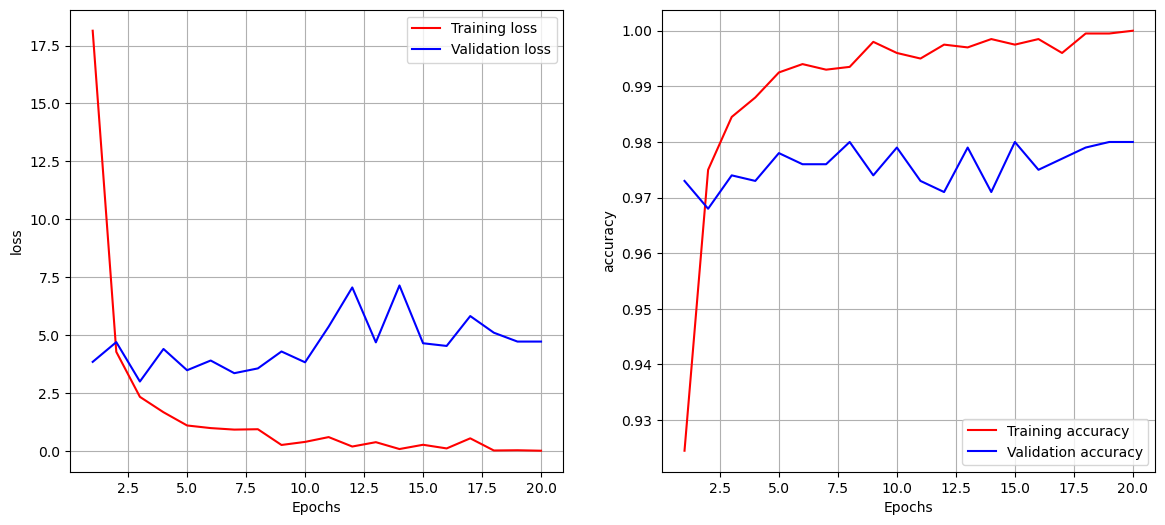

In [21]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

In [26]:
test_model = keras.models.load_model("../models/ch08-feature-extraction.keras")
test_loss, test_acc = test_model.evaluate(test_features, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9662 - loss: 7.1943
Test accuracy: 0.970


We reach a validation accuracy of above 97%, much better than we achieved with a model trained from scratch.  This is due to the
power of the feature maps learned by the VGG16 convolutional layers on a very large amount of data.

However the plot indicates were are overfitting fairly quickly.  Training loss goes to 0 and validation loss is rising a bit  That's because
this technique doesn't use data augmentation which is essential for preventing overfitting with small
image datasets.

#### Feature extraction together with data augmentation

Now for the second technique for doing feature extraction,
which is much slower and more expensive, but which allows us to use data augmentation
during training: creating a model that chains the `conv_base` with a new dense
classifier, and training it end to end on the inputs.


In order to do this, we will first **freeze the convolutional base**. Freezing a layer or set of
layers means preventing their weights from being updated during training.

In Keras, we freeze a layer or model by setting its trainable attribute to False.

In [27]:
# load it again, and freeze the convolutional bases weights so we don't
# destroy the learned features when training with it
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False)
conv_base.trainable = False

Setting `trainable` to `False` empties the list of trainable weights of the layer or model.

In [28]:
conv_base.trainable = True
print("This is the number of trainable weights "
      "before freezing the conv base:", len(conv_base.trainable_weights))

This is the number of trainable weights before freezing the conv base: 26


In [29]:
conv_base.trainable = False
print("This is the number of trainable weights "
      "after freezing the conv base:", len(conv_base.trainable_weights))

This is the number of trainable weights after freezing the conv base: 0


Now we can create a new model that chains together

1. A data augmentation stage
2. Our frozen convolutional base
3. A trainable dense classifier

In [30]:
# use same sequence of augmentation layers as we did previously
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

# build model chaining together the 3 pieces
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

# compile the model to make it ready for training
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

With this setup where we froce the weights in the `conv_base`, only the weights in the
two final `Dense` layers will be trained.  

**Note**: Weight trainability is fixed by the compile step.  If you ever modify some weights to be trainable or
untrainable in a model, you have to recompile after freezing or unfreezing.

Let's train our model.  Thanks to data augmentation, it will take much longer for the model
to start overfitting, so we need to train for more epochs, let's use 50.

**Note**: This technique is expensive enough that you might find it painful to run on CPU only.
On an NVidia 3060 it takes 7-10s per epoch, so a total of 500 or less seconds.  
When I run on my CPU epochs take X seconds now so a total of Y seconds.

In [31]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="../models/ch08-feature-extraction-with-data-augmentation.keras",
        save_best_only=True,
        monitor="val_loss")
]

history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 138ms/step - accuracy: 0.8497 - loss: 37.4175 - val_accuracy: 0.9680 - val_loss: 5.2246
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - accuracy: 0.9537 - loss: 6.6199 - val_accuracy: 0.9770 - val_loss: 4.2027
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.9576 - loss: 4.7150 - val_accuracy: 0.9700 - val_loss: 5.9543
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - accuracy: 0.9624 - loss: 4.6386 - val_accuracy: 0.9730 - val_loss: 3.9004
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.9657 - loss: 4.1262 - val_accuracy: 0.9570 - val_loss: 8.0096
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - accuracy: 0.9762 - loss: 2.7804 - val_accuracy: 0.9750 - val_loss: 3.5301
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.9722 - loss: 3.1965 - val_accuracy: 0.9790 - val_loss: 3.9175
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.9668 - loss: 4.0077 - val_accuracy: 

As usual lets check the learning curves again.  As you should usually see we reach a validation
accuracy of over 98%.

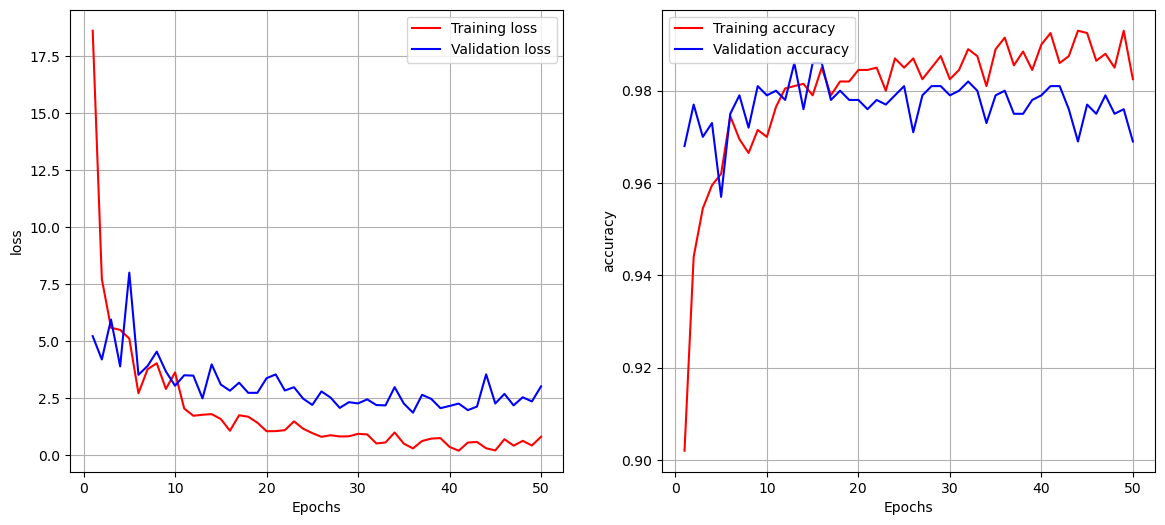

In [32]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

Let's see what the final test accuracy is.

In [33]:
test_model = keras.models.load_model(
    "../models/ch08-feature-extraction-with-data-augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9787 - loss: 1.5398
Test accuracy: 0.978


You usually should get a test accuracy over 97.5%, a modest but probably significant improvement over the previous model.

This is a bit disappointing.  A model's accuracy always depends on the set of samples you evaluate it on!
Some sample sets may be more difficult than others, and strong results on one set won't necessarily fully translate to all other
sets.

### Fine-tuning a Pretrained Model

Another widely used technique for model reuse,
complementary to feature extraction, is fine-tuning.

Fine-tuning consists of unfreezing
a few of the top layers of a frozen model base used
for feature extraction, and jointly training both the
newly added part of the model (in this case, the
fully connected classifier) and these top layers.

it’s only possible to fine-tune the top
layers of the convolutional base once the classifier on
top has already been trained. If the classifier isn’t
already trained, the error signal propagating
through the network during training will be too
large, and the representations previously learned by
the layers being fine-tuned will be destroyed.

Thus the steps for fine-tuning a network are:

1. Add our custom network ontop of an already-trained base network.
2. Freeze the base network
3. Train the part we added
4. Unfreeze some layers in the base network.
5. Jointly train both these layers and the part we added.

We already completed steps 1-3 above.  We can try to fine-tune the upper
feature layers by unfreezing some of them and jointly training some more.

We'll fine-tune the last 3 convolutional layers, which means all layers up to 
`block4_pool` should remai frozen, and layers `block5_conv1`, `block5_conv2`
and `block5_conv3` should be trainable.

In [34]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [35]:
# unfreeze, but then refreeze all layers until the fourth from the last
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False

Now we can begin fine-tuning the model.  We'll do this with the `RMSprop` optimizer using a 
very low learning rate.  The reason is that we want to limit the magnitude of the modifications
we make to the representation of the three layers we're fine tuning.

We need to recompile the model, both to set the learning rate, and also because we changed
which weights are trainable.

In [36]:
model.compile(loss="binary_crossentropy",
              optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
              metrics=["accuracy"])

In [37]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="../models/ch08-fine-tuning.keras",
        save_best_only=True,
        monitor="val_loss")
]

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - accuracy: 0.9913 - loss: 0.3869 - val_accuracy: 0.9770 - val_loss: 2.0726
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.9936 - loss: 0.3204 - val_accuracy: 0.9750 - val_loss: 1.8657
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.9838 - loss: 0.3923 - val_accuracy: 0.9830 - val_loss: 1.8460
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.9926 - loss: 0.1880 - val_accuracy: 0.9780 - val_loss: 2.2053
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.9964 - loss: 0.1217 - val_accuracy: 0.9770 - val_loss: 1.9617
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.9900 - loss: 0.3680 - val_accuracy: 0.9790 - val_loss: 2.1307
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.9935 - loss: 0.1642 - val_accuracy: 0.9760 - val_loss: 1.8885
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.9924 - loss: 0.2976 - val_accuracy: 0

We can evaluate the model on the test data now.

In [38]:
model = keras.models.load_model("../models/ch08-fine-tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9757 - loss: 0.9272
Test accuracy: 0.976


Here you usually will see some improvement over the previous 2 attempts, something like 98.5% accuracy.

In the original Kaggle competition around this dataset, this would
have been one of the top results. It’s not quite a fair comparison, since we
used pretrained features that already contained prior knowledge about cats and dogs,
which competitors couldn’t use at the time.

On the positive side, by leveraging modern deep learning techniques, we managed
to reach this result using only a small fraction of the training data that was available
for the competition (about 10%). There is a huge difference between being able to
train on 20,000 samples compared to 2,000 samples!

## Summary

Some of the things to remember about leveraging pretrained models

<font color='blue'>

- Pretrained models on large imaging datasets are available through the Keras API and from other methods.
- The convolutional layers of such pretrained models have learned a powerful and useful hierarchy of
  features, from the low level to the more abstract.
- Leveraging a pretrained model can help get excelent image classification results if even only have a (relatively) small set of images to train with.
- There are two basic approaches to using a pretrained model
  1. Extract features by passing inputs into pretrained model and gathering last convolutional layer outputs.  This is computationally faster, but you can't
     use data augmentation or other fine tuning techniques with this approach.
  2. Freeze the weights of the pretrained model and add in your data augmentation stage before and classifier after, and retrain from begin to end using
     your data augmentation.  Computationally more expensive but can be fine-tuned better.
- Can also help to sometime first train a model with frozen pretrained weights, then unfreeze some of the top layers of the pretrained model and train some more.

## Chapter Summary

Some of the things to remember about leveraging pretrained models

<font color='blue'>

- Convnets are the best type of machine learning models for computer vision
  tasks. It’s possible to train one from scratch even on a very small dataset, with
  decent results.
- Convnets work by learning a hierarchy of modular patterns and concepts to
  represent the visual world.
- On a small dataset, overfitting will be the main issue. Data augmentation is a
  powerful way to fight overfitting when you’re working with image data.
- It’s easy to reuse an existing convnet on a new dataset via feature extraction.
  This is a valuable technique for working with small image datasets.
- As a complement to feature extraction, you can use fine-tuning, which adapts to
  a new problem some of the representations previously learned by an existing
  model. This pushes performance a bit further.